In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv('Breast Cancer Data Set.csv')

In [4]:
# Verify that the file loaded correctly by displaying the shape and top rows
print(f"Initial Dataset Shape: {df.shape}")
df.head()

Initial Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Cell 2: Quality Inspection
# Check for any missing values across all columns
missing_count = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {missing_count}")

Total Missing Values in Dataset: 0


In [6]:
# Check for completely duplicated patient rows
duplicate_count = df.duplicated().sum()
print(f"Total Duplicated Rows: {duplicate_count}")

Total Duplicated Rows: 0


In [7]:
# Cell 3: Feature Drop
# Remove 'id' column; use errors='ignore' to prevent crashes if rerun
df_dropped = df.drop(columns=["id"], errors="ignore")

In [8]:
# Print the columns left to make sure 'id' was successfully excluded
print(f"Remaining Columns count: {len(df_dropped.columns)}")
print("Columns list:", list(df_dropped.columns[:5]), "...etc")

Remaining Columns count: 31
Columns list: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ...etc


In [9]:
# Cell 4: Column Label Formatting
# Strip edge spaces and replace internal spaces with underscores
df_dropped.columns = df_dropped.columns.str.strip().str.replace(" ", "_")

In [10]:
# Show cleaned column names to verify formatting changes
print("Sanitized Column Headers Preview:")
print(df_dropped.columns[:5])

Sanitized Column Headers Preview:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean'],
      dtype='object')


In [11]:
# Cell 5: Label Encoding
# Create a dictionary map: Malignant tumor becomes 1, Benign tumor becomes 0
diagnosis_map = {"M": 1, "B": 0}

In [12]:
# Overwrite the text labels with the binary integers
df_dropped["diagnosis"] = df_dropped["diagnosis"].map(diagnosis_map)

In [13]:
# Confirm conversion by displaying value frequencies
print("Encoded Target Variable Distribution:")
print(df_dropped["diagnosis"].value_counts())

Encoded Target Variable Distribution:
0    357
1    212
Name: diagnosis, dtype: int64


In [14]:
# Cell 6: Data Finalization and Export
# Transfer clean mutations into our final dataframe object
cleaned_breast_cancer_df = df_dropped.copy()

In [15]:
# Save the final table to disk without retaining the Pandas index numbers
cleaned_breast_cancer_df.to_csv("cleaned_breast_cancer_data.csv", index=False)
print("SUCCESS: Your cleaned data is saved as 'cleaned_breast_cancer_data.csv'!")

SUCCESS: Your cleaned data is saved as 'cleaned_breast_cancer_data.csv'!


In [16]:
# Final visual check of the dataframe
cleaned_breast_cancer_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [35]:
df=cleaned_breast_cancer_df.head()

In [36]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, skew

In [37]:
# Check normal distribution using Shapiro-Wilk test and Skewness
normality_results = []
for col in df_numeric.columns:
    stat, p_value = shapiro(df_numeric[col])
    sk = skew(df_numeric[col])
    # If p-value > 0.05, it's normally distributed
    is_normal = "Yes" if p_value > 0.05 else "No"
    normality_results.append({
        "Variable": col,
        "Skewness": round(sk, 4),
        "Shapiro-Stat": round(stat, 4),
        "P-Value": p_value,
        "Normally Distributed": is_normal
    })

In [23]:
normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string())

                   Variable  Skewness  Shapiro-Stat   P-Value Normally Distributed
0               radius_mean   -1.2639        0.7594  0.036258                   No
1              texture_mean   -0.4628        0.9327  0.614844                  Yes
2            perimeter_mean   -1.3670        0.7187  0.014875                   No
3                 area_mean   -1.1433        0.8030  0.085728                  Yes
4           smoothness_mean    0.3287        0.9867  0.966724                  Yes
5          compactness_mean    0.0913        0.8897  0.355409                  Yes
6            concavity_mean   -0.4230        0.9500  0.737121                  Yes
7       concave_points_mean   -0.1862        0.9685  0.865349                  Yes
8             symmetry_mean    0.2675        0.8828  0.322137                  Yes
9    fractal_dimension_mean    0.7945        0.8265  0.130845                  Yes
10                radius_se    0.6552        0.9043  0.433973                  Yes
11  

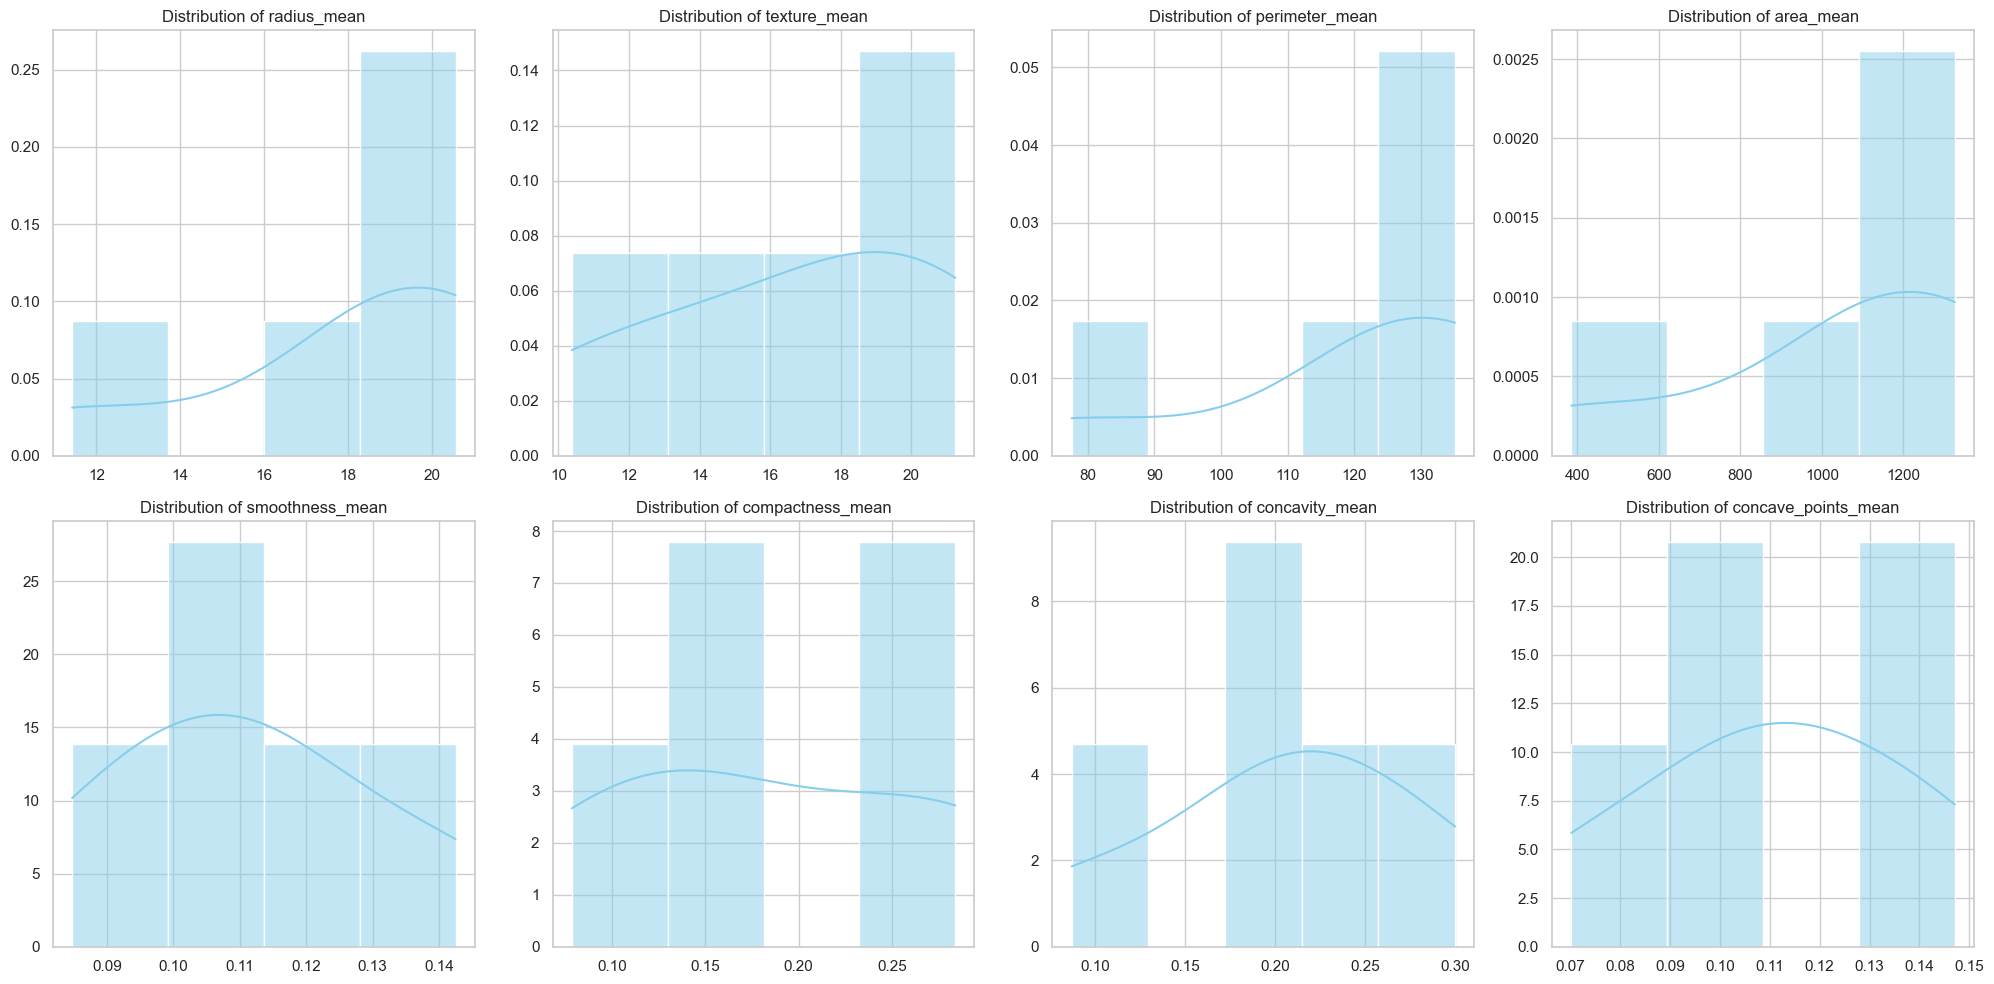

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your original DataFrame containing the actual data columns 
# (e.g., df['radius_mean'], df['texture_mean'], etc.)

# 1. Set up the plotting style
sns.set_theme(style="whitegrid")

# 2. Define the columns you want to plot (taking the list from your normality dataframe)
columns_to_plot = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean'
    # Add more or use df.columns if you want to plot all of them
]

# 3. Create a grid of subplots (e.g., 2 rows x 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten the 2D array of axes to easily loop through them

# 4. Loop through the columns and plot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # histplot with kde=True plots the histogram and a smooth density curve
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="skyblue", stat="density")
        
        # Add a title to each subplot for clarity
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

# 5. Adjust layout so titles and labels don't overlap
plt.tight_layout()

# 6. Display the plot
plt.show()

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

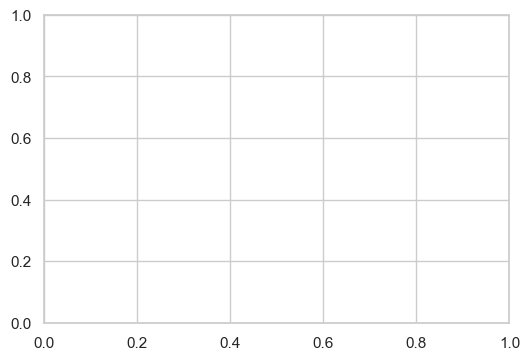

In [26]:
# 1. Target Distribution (Fixed Code)
fig, ax = plt.subplots(figsize=(6, 4))

<AxesSubplot:xlabel='diagnosis', ylabel='count'>

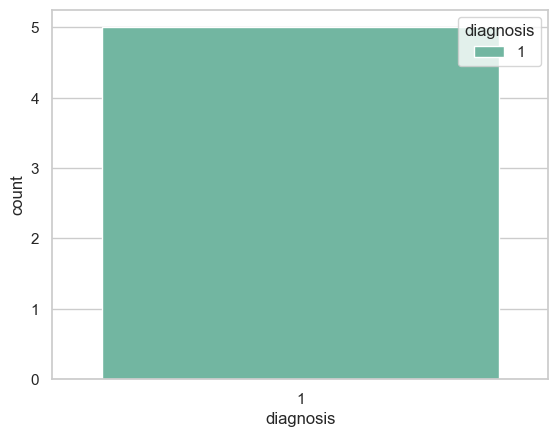

In [39]:
# Humne yahan se 'legend=False' remove kar diya hai taake purane versions par error na aaye
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='Set2')

In [40]:
# Agar automatic legend banti hai to use yahan se remove kar dete hain
if ax.get_legend() is not None:
    ax.get_legend().remove()

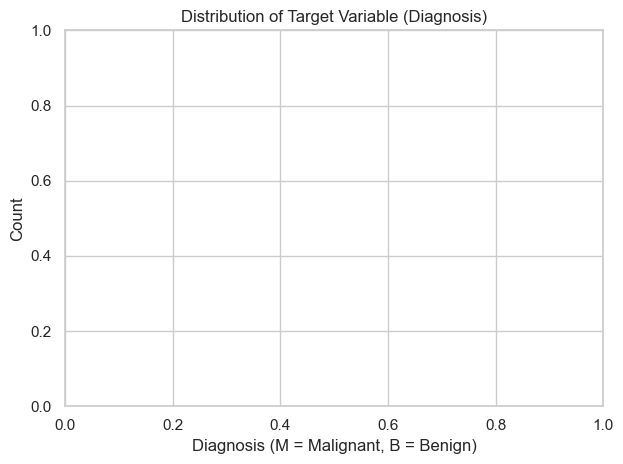

In [29]:
plt.title('Distribution of Target Variable (Diagnosis)')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show() # Jupyter notebook mein view karne ke liye .show() use karein

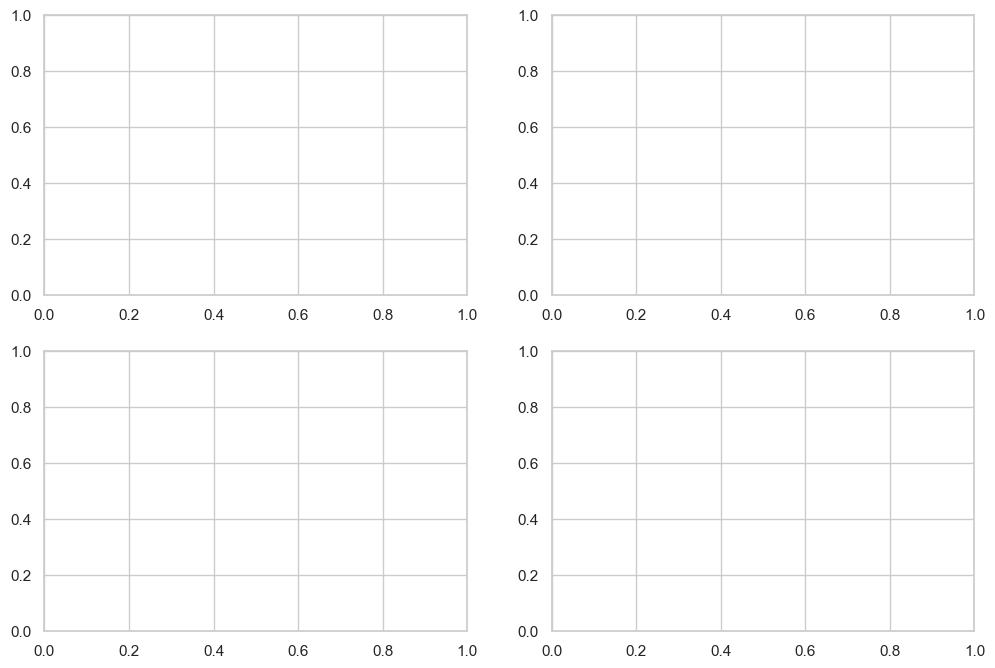

In [41]:
# Cell 3: Distribution Plots for Key Features
mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

In [42]:
for i, col in enumerate(mean_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

In [43]:
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

<Figure size 640x480 with 0 Axes>

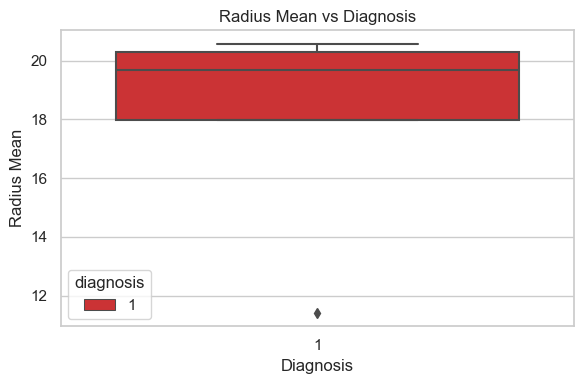

In [33]:
# Cell 4: Boxplot to check variance across groups
plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='diagnosis', y='radius_mean', hue='diagnosis', palette='Set1')
plt.title('Radius Mean vs Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Radius Mean')
plt.tight_layout()
plt.savefig('boxplot_radius_vs_diagnosis.png')
plt.show()

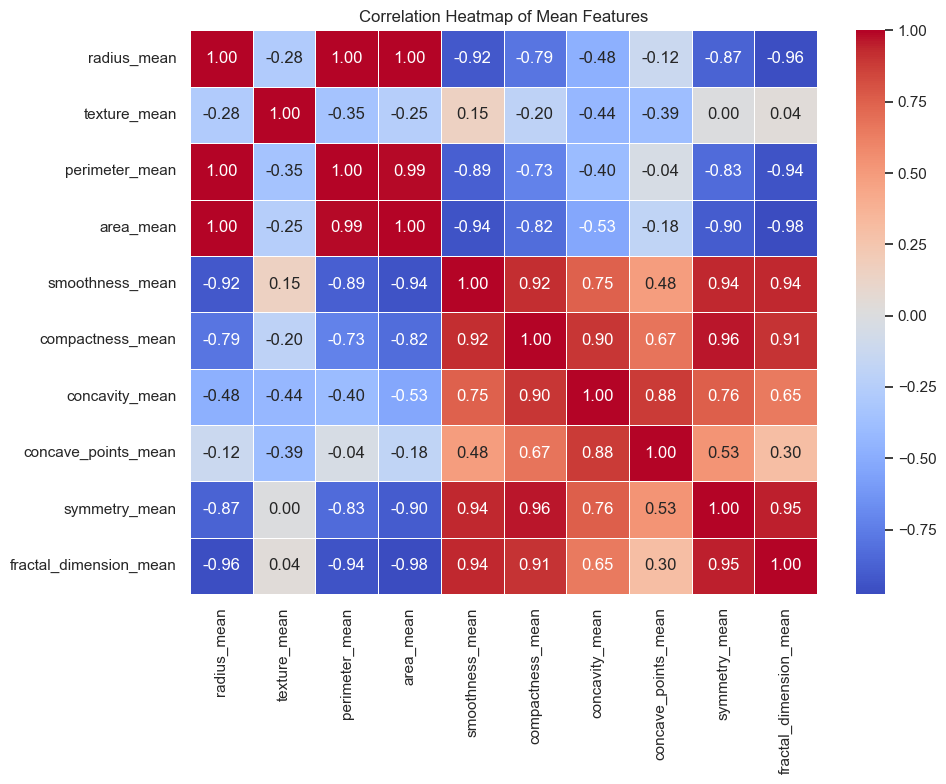

In [44]:
# Cell 5: Correlation Heatmap for all '_mean' features
mean_cols = [col for col in df.columns if '_mean' in col]
corr_matrix = df[mean_cols].corr()

plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Mean Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [45]:
# Cell: Correlation of Diagnosis with Mean Features
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# 2. '_mean' wale columns ke sath 'diagnosis' column ko bhi select karein
mean_cols = [col for col in df.columns if '_mean' in col]
cols_to_correlate = ['diagnosis'] + mean_cols  # 'diagnosis' ko list ke shuru mein jor diya

In [48]:
# 3. Correlation matrix nikalyein
corr_matrix = df[cols_to_correlate].corr()

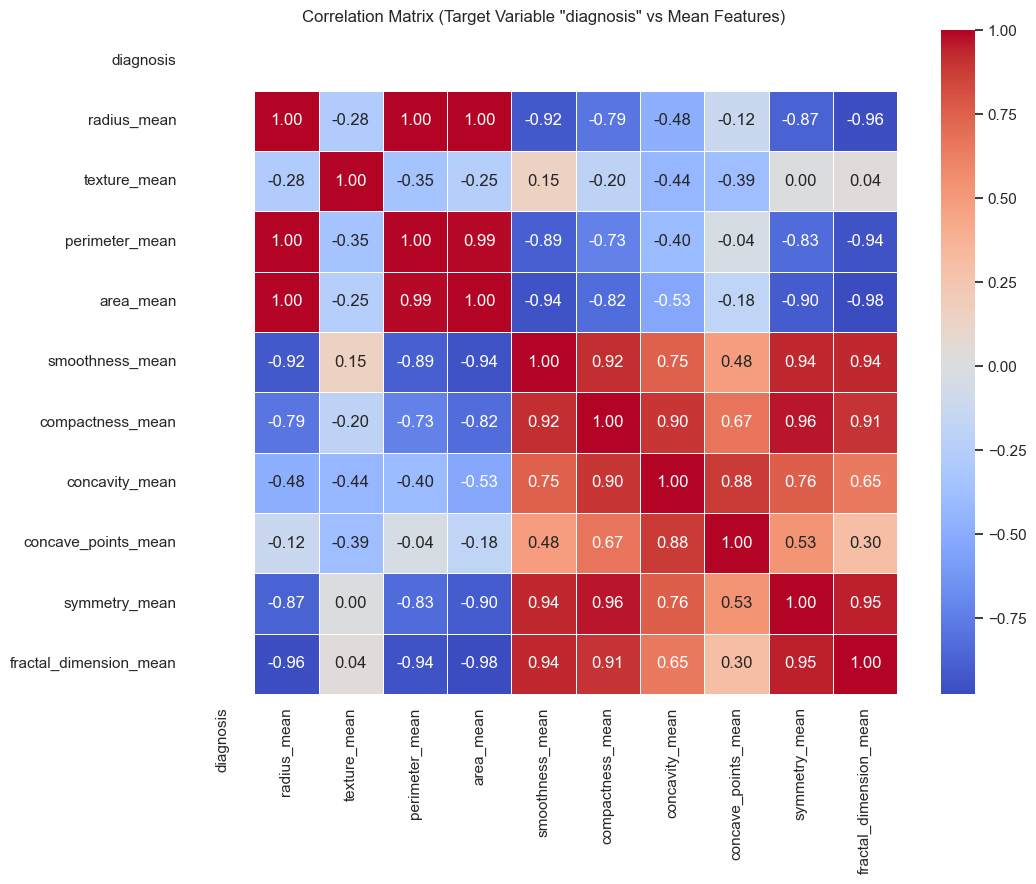

In [49]:
# 4. Heatmap plot karein
plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Target Variable "diagnosis" vs Mean Features)')
plt.tight_layout()
plt.show()

In [67]:
import numpy as np

# Create correlation matrix
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Suggested columns to drop due to high correlation: {to_drop}")
# df_cleaned = df.drop(columns=to_drop)

Suggested columns to drop due to high correlation: ['perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se', 'area_se', 'compactness_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


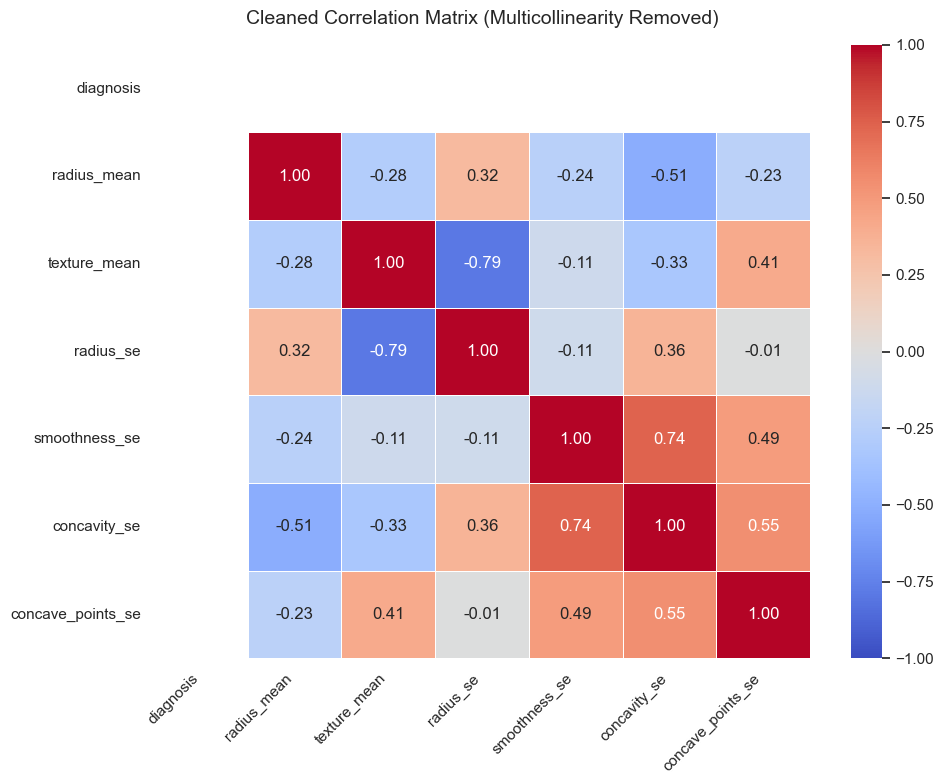

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the absolute correlation matrix
corr_matrix = df.corr()
abs_corr = corr_matrix.abs()

# 2. Select upper triangle of correlation matrix (to avoid checking a pairs twice)
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

# 3. Find features with a correlation greater than 0.85
# (Keeping the first feature encountered, dropping subsequent ones)
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

# 4. Drop the highly correlated features
df_reduced = df.drop(columns=to_drop)

# 5. Plot the new, cleaned correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_reduced.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmax=1.0, 
    vmin=-1.0, 
    linewidths=0.5
)

plt.title('Cleaned Correlation Matrix (Multicollinearity Removed)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()